# UdaSense: Optimized Object Recognition

## Notebook 3: Multi-step Optimization Pipeline

 
In this notebook, you'll implement the multi-step optimization pipeline based on the findings from the previous experiments. The goal is to combine different optimization techniques to meet all requirements:

- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You may need to experiment with different pipelines as you try to hit your targets. Make sure to start with those that are easier to implement!

### Overview: Implementation Plan



In this notebook I will design, implement, and evaluate a multi-step optimization pipeline that combines the most promising techniques from the baseline and `02_compression.ipynb` experiments.



1. **Load data and baseline reference**  

   Use the CIFAR household loaders and the pre-trained `MobileNetV3_Household` baseline plus its saved metrics. Derive the concrete target values for size, latency (CPU/GPU), and accuracy from the CTO requirements so every pipeline can be judged against the same numbers.



2. **Define reusable pipeline step helpers**  

   Implement small, self-contained functions that wrap individual techniques behind a common interface used by `OptimizationPipeline.run(...)`:

   - Dynamic post-training quantization on CPU (via `quantize_model`),

   - Graph optimization via TorchScript / FX (via `optimize_model`),

   - Placeholders for in-training techniques (KD, pruning, QAT) that can be filled in later if needed.  

   Each step will be responsible for: (a) producing an updated model, (b) saving artifacts under `models/pipeline/<pipeline_name>/...`, and (c) returning metrics/comparison objects via `evaluate_optimized_model` and `compare_optimized_model_to_baseline`.



3. **Construct concrete pipelines**  

   Start with a simple, robust pipeline that chains **dynamic PTQ → TorchScript graph optimization** (already partially wired as Pipeline #1) and run it on CPU, since that is the primary latency target. Optionally define additional pipelines that explore alternative orderings or add further steps (e.g., KD or pruning first, then PTQ and/or graph optimization) if accuracy and stability allow.



4. **Run pipelines and collect per-step metrics**  

   For each pipeline, call `OptimizationPipeline.run(...)` to sequentially execute the configured steps. After every step, record size, parameter count, latency (per device), and accuracy in `results/pipeline/<pipeline_name>/pipeline_metrics.json`, ensuring that each intermediate experiment is also saved under its own `./results/<experiment_name>/metrics.json` directory.



5. **Visualize progression within a pipeline**  

   Use `OptimizationPipeline.visualize_results(...)` to generate plots that compare the baseline to each step in the pipeline for model size, parameter count, latency, and accuracy, and overlay the CTO thresholds to quickly see which steps help or hurt.



6. **Compare all pipelines holistically**  

   Use `list_experiments("./results/pipeline/")` together with `compare_experiments(...)` to summarise all pipeline steps across all pipelines in a single table. Identify which configuration best balances size reduction, speedup, and accuracy retention and whether any pipeline fully satisfies the CTO requirements.



7. **Select the final pipeline and document insights**  

   Based on the quantitative results, choose a final “production” pipeline (likely the dynamic PTQ + TorchScript pipeline, given its strong trade-off between accuracy and efficiency). Summarise why this configuration is preferred, which techniques were rejected (and why), and how system-level constraints (e.g., already low baseline latency) influence what improvements are realistically achievable. These conclusions will feed into the final report and the deployment work in `04_deployment.ipynb`.

### Step 1: Set up the environment

In [12]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import sys
from pathlib import Path

# Resolve the absolute path of the *project root* inside project-showroom
# Adjust `project_showroom_root` to your layout if needed
project_showroom_root = Path.cwd().resolve()

# Add the udasense project root to Python path
udasense_root = project_showroom_root # / "./"  # or whatever the folder is called
sys.path.insert(0, str(udasense_root))

print("Added to PYTHONPATH:", udasense_root)

# Set current working directory to udasense project root
%cd {udasense_root}
print("Current working directory:", Path.cwd())

Added to PYTHONPATH: /home/oliver/project-showroom/projects/model-opt/UdaSense-sense
/home/oliver/project-showroom/projects/model-opt/UdaSense-sense
Current working directory: /home/oliver/project-showroom/projects/model-opt/UdaSense-sense


In [2]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [14]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [15]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA GeForce RTX 4070 Laptop GPU)']


In [16]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


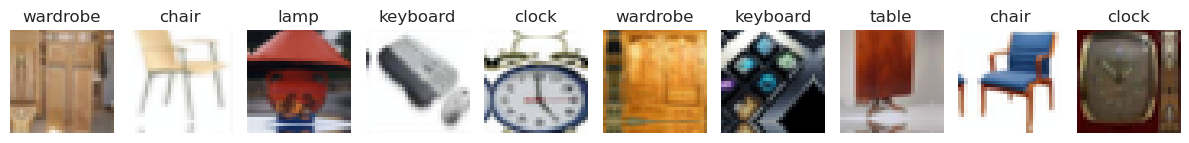


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


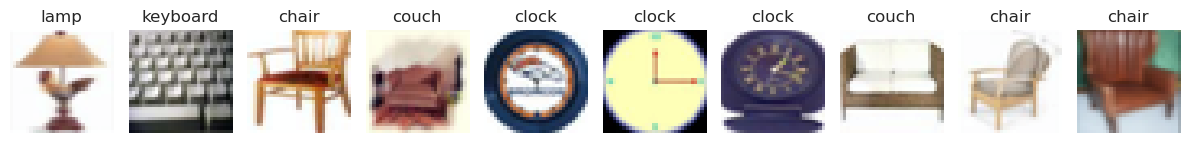

In [17]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=64, num_workers=4,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [18]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"./models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"./results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate optimization pipelines

Based on your analysis in the previous notebook, you'll implement and evaluate different multi-step pipelines to find the optimal approach for meeting all requirements.

In [19]:
class OptimizationPipeline:
    def __init__(self, name, baseline_model, train_loader, test_loader, class_names, input_size):
        """
        Initialize the optimization pipeline.
        
        Args:
            name: Name of the pipeline for tracking and saving
            baseline_model: The baseline model to optimize
            train_loader: DataLoader for training data (needed for some optimization techniques)
            test_loader: DataLoader for testing data (needed for evaluation)
            class_names: List of class names in the dataset
            input_size: Input tensor size
        """
        self.name = name
        self.baseline_model = baseline_model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.input_size = input_size
        self.optimized_model = None
        self.steps = []
        self.results = {}
        
        # Create directories for this pipeline
        self.model_dir = f"./models/pipeline/{name}"
        self.checkpoint_dir = f"{self.model_dir}/checkpoints"
        self.results_dir = f"./results/pipeline/{name}"
        
        for d in [self.model_dir, self.checkpoint_dir, self.results_dir]:
            os.makedirs(d, exist_ok=True)
    
    def add_step(self, step_name, step_function, **kwargs):
        """
        Add an optimization step to the pipeline.
        
        Args:
            step_name: Name of the step
            step_function: Function that implements the step
            **kwargs: Arguments to pass to the step function
        """
        self.steps.append({
            'name': step_name,
            'function': step_function,
            'args': kwargs
        })

    def run(self, device=torch.device('cpu'), file_extension='pth'):
        """
        Run the optimization pipeline.
        
        Args:
            device: Device to run the pipeline on (used as default for steps)
            file_extension: File extension to save the final model with
                            ('.pt' for TorchScript, otherwise '.pth')
            
        Returns:
            The optimized model
        """
        print(f"\n{'='*50}")
        print(f"Running pipeline: {self.name}")
        print(f"{'='*50}\n")
        
        # Start with the baseline model
        current_model = self.baseline_model
        current_model.to(device)

        # Save intermediate results after each step
        step_results = []

        # Common context passed to all step functions
        experiment_root = f"pipeline/{self.name}"
        context = {
            "train_loader": self.train_loader,
            "test_loader": self.test_loader,
            "class_names": self.class_names,
            "input_size": self.input_size,
            "device": device,
            "baseline_model": self.baseline_model,
            "experiment_root": experiment_root,
        }
        
        # Run the pipeline iteratively
        # For each stage in the pipeline:
        # 1. Apply the specified technique with the given parameters
        # 2. Evaluate the model after applying the technique
        # 3. Store the results for later comparison
        for i, step in enumerate(self.steps):
            print(f"\n{'-'*50}")
            print(f"Step {i+1}: {step['name']}")
            print(f"{'-'*50}\n")
            
            step_fn = step["function"]
            step_args = step["args"]

            # Call the step function with the current model and shared context
            optimized_model, metrics, comparison_results, experiment_name, serializable_model = step_fn(
                current_model,
                **context,
                **step_args,
            )

            # Store step results in a format that visualize_results expects
            step_results.append({
                "step_name": step["name"],
                "experiment_name": experiment_name,
                "metrics": metrics,
                "comparison": comparison_results,
            })

            # Feed the optimized model into the next step
            current_model = optimized_model

        # If no steps were run, keep the baseline model
        if not step_results:
            print("Warning: pipeline has no steps, keeping baseline model as optimized_model.")
            self.optimized_model = self.baseline_model
            final_metrics = None
            final_comparison = None
        else:
            self.optimized_model = current_model
            final_metrics = step_results[-1]["metrics"]
            final_comparison = step_results[-1]["comparison"]

        final_path = f"{self.model_dir}/model.{file_extension}"
        
        # Save final model
        # If file_extension == 'pt' we assume a TorchScript model, otherwise a regular nn.Module
        try:
            if file_extension == 'pt':
                # TorchScript save
                torch.jit.save(serializable_model, final_path)
            else:
                # Standard PyTorch module save using the provided utility
                save_model(self.optimized_model, final_path)
            print(f"Final model saved to: {final_path}")
        except Exception as e:
            print(f"Warning: failed to save final model to {final_path}: {e}")

        # Save pipeline results
        self.results = {
            "pipeline_name": self.name,
            "steps": step_results,
            "final_metrics": final_metrics,
            "final_comparison": final_comparison,
        }
        
        with open(f"{self.results_dir}/pipeline_metrics.json", 'w') as f:
            json.dump(self.results, f, indent=4)
        
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} completed")
        print(f"{'='*50}\n")
        
        return self.optimized_model

    
    def visualize_results(self, baseline_metrics=baseline_metrics, device=torch.device('cpu')):
        """
        Visualize the results of the pipeline.

        Args:
            baseline_metrics: Dictionary of baseline metrics for comparison.
            device: Device to run the pipeline on

        """
        if not self.results:
            print("No results to visualize. Please run the pipeline first.")
            return

        # Define device name
        device_name = 'cpu' if device==torch.device('cpu') else 'cuda'

        # Extract metrics from each step
        step_names = [step['step_name'] for step in self.results['steps']]
        model_sizes = [step['metrics']['size']['model_size_mb'] for step in self.results['steps']]
        model_memory_sizes = [step['metrics']['size']['total_params'] for step in self.results['steps']]
        times = [step['metrics']['timing'][device_name]['avg_time_ms'] for step in self.results['steps']]
        accuracies = [step['metrics']['accuracy']['top1_acc'] for step in self.results['steps']]

        # Add baseline metrics
        step_names.insert(0, 'Baseline')
        baseline_size = baseline_metrics['size']['model_size_mb']
        baseline_memory_size = baseline_metrics['size']['total_params']
        baseline_inference_time = baseline_metrics['timing'][device_name]['avg_time_ms']
        baseline_accuracy = baseline_metrics['accuracy']['top1_acc']

        model_sizes.insert(0, baseline_size)
        model_memory_sizes.insert(0, baseline_memory_size)
        times.insert(0, baseline_inference_time)
        accuracies.insert(0, baseline_accuracy)

        # Create figure with subplots
        fig, axes = plt.subplots(4, 1, figsize=(12, 15))

        # Plot model size
        axes[0].bar(step_names, model_sizes, color='blue')
        axes[0].set_title('Model Size (MB)')
        axes[0].set_ylabel('Size (MB)')
        axes[0].axhline(y=baseline_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[0].legend()
        for i, v in enumerate(model_sizes):
            axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center')

        axes[1].bar(step_names, model_memory_sizes, color='blue')
        axes[1].set_title('Model Size (# Parameters)')
        axes[1].set_ylabel('Peak Memory')
        axes[1].axhline(y=baseline_memory_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[1].legend()
        for i, v in enumerate(model_memory_sizes):
            axes[1].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot inference time
        axes[2].bar(step_names, times, color='green')
        axes[2].set_title('Inference Time (ms)')
        axes[2].set_ylabel('Time (ms)')
        axes[2].axhline(y=baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP), color='r', linestyle='--', label=f"Target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        axes[2].legend()
        for i, v in enumerate(times):
            axes[2].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot accuracy
        axes[3].bar(step_names, accuracies, color='purple')
        axes[3].set_title('Top-1 Accuracy (%)')
        axes[3].set_ylabel('Accuracy (%)')
        axes[3].axhline(y=baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP), color='r', linestyle='--', label=f"Minimum acceptable ({MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        axes[3].legend()
        for i, v in enumerate(accuracies):
            axes[3].text(i, v + 0.5, f"{v:.2f}%", ha='center')

        plt.tight_layout()
        plt.savefig(f"{self.results_dir}/pipeline_visualization.png")
        plt.show()

        # Print final results summary
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} Results Summary")
        print(f"{'='*50}")

        # Size comparison
        size_reduction = (baseline_size - model_sizes[-1]) / baseline_size * 100
        print(f"\nModel Size (MB):")
        print(f"  Baseline: {baseline_size:.2f} MB")
        print(f"  Final: {model_sizes[-1]:.2f} MB")
        print(f"  Reduction: {size_reduction:.2f}%")
        target_size = baseline_size * (1-TARGET_MODEL_COMPRESSION)
        if model_sizes[-1] <= target_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_size:.2f} MB)")

        memory_size_reduction = (baseline_memory_size - model_memory_sizes[-1]) / baseline_memory_size * 100
        print(f"\nModel Size (# Parameters):")
        print(f"  Baseline: {baseline_memory_size:.2f} MB")
        print(f"  Final: {model_memory_sizes[-1]:.2f} MB")
        print(f"  Reduction: {memory_size_reduction:.2f}%")
        target_memory_size = baseline_memory_size * (1-TARGET_MODEL_COMPRESSION)
        if model_memory_sizes[-1] <= target_memory_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_memory_size:.2f} MB)")


        # Inference time comparison
        time_reduction = (baseline_inference_time - times[-1]) / baseline_inference_time * 100
        print(f"\nInference Time (CPU):")
        print(f"  Baseline: {baseline_inference_time:.2f} ms")
        print(f"  Final: {times[-1]:.2f} ms")
        print(f"  Reduction: {time_reduction:.2f}%")
        target_time = baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP)
        if times[-1] <= target_time:
            print(f"  ✅ Meets target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_time:.2f} ms)")

        # Accuracy comparison
        accuracy_change = (accuracies[-1] - baseline_accuracy) / baseline_accuracy * 100
        print(f"\nAccuracy:")
        print(f"  Baseline: {baseline_accuracy:.2f}%")
        print(f"  Final: {accuracies[-1]:.2f}%")
        print(f"  Change: {accuracy_change:.2f}%")
        min_acceptable = baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP)
        if accuracies[-1] >= min_acceptable:
            print(f"  ✅ Meets target (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        else:
            print(f"  ❌ Does not meet target (Goal: ≥{min_acceptable:.2f}%)")

        # Overall assessment
        print(f"\nOverall Assessment:")
        if model_sizes[-1] <= target_size and times[-1] <= target_time and accuracies[-1] >= min_acceptable:
            print(f"  ✅ Pipeline meets all requirements")
        else:
            print(f"  ❌ Pipeline does not meet all requirements")

In [20]:
# Remember to parametrize the functions appropriately
def apply_post_training_pruning():
    pass

def apply_dynamic_quantization(
    model,
    train_loader,
    test_loader,
    class_names,
    input_size,
    device,
    baseline_model,
    experiment_root,
    backend="fbgemm",
    step_name="dynamic_quantization",
):
    """
    Apply dynamic post training quantization as a pipeline step.

    Args:
        model: The current model in the pipeline.
        train_loader: DataLoader for training data (unused for dynamic quantization,
                      but kept for interface consistency).
        test_loader: DataLoader for evaluation.
        class_names: List of class names.
        input_size: Input tensor size used for evaluation.
        device: Device the pipeline is currently configured with.
        baseline_model: The original baseline model for comparison.
        experiment_root: Root experiment name, typically something like
                         f"pipeline/{pipeline_name}".        
        backend: Quantization backend, e.g. "fbgemm".
        step_name: Suffix used to build the experiment_name.

    Returns:
        optimized_model: The quantized model.
        metrics: Metrics dict as returned by evaluate_optimized_model.
        comparison_results: Comparison dict as returned by compare_optimized_model_to_baseline.
        experiment_name: Experiment identifier used in ./models and ./results.
        serializable_model: A version of the model that can be serialized.
    """
    # For dynamic quantization we always operate and evaluate on CPU
    device_for_opt = torch.device("cpu")

    # Build experiment name under the pipeline namespace
    # Example: pipeline/p1_dynq_then_ts/dynamic_quantization_fbgemm
    experiment_name = os.path.join(experiment_root, f"{step_name}_{backend}")
    models_dir = f"./models/{experiment_name}"
    results_dir = f"./results/{experiment_name}"
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    print(f"\n[Pipeline] Applying dynamic quantization with backend={backend}")
    print(f"[Pipeline] Experiment name: {experiment_name}")

    # Move model to CPU for quantization
    model_for_ptq = model.to(device_for_opt)
    model_for_ptq.eval()

    # Apply dynamic post training quantization
    quantized_model = quantize_model(
        model_for_ptq,
        quantization_type="dynamic",
        calibration_data_loader=None,
        calibration_num_batches=None,
        backend=backend,
    )

    # Save the quantized model
    save_model(quantized_model, f"{models_dir}/model.pth")

    # Evaluate quantized model on CPU
    metrics, _ = evaluate_optimized_model(
        quantized_model,
        test_loader,
        experiment_name,
        class_names,
        input_size,
        device=device_for_opt,
    )

    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device_for_opt,
    )

    return quantized_model, metrics, comparison_results, experiment_name, quantized_model


def apply_graph_optimization(
    model,
    train_loader,
    test_loader,
    class_names,
    input_size,
    device,
    baseline_model,
    experiment_root,
    optimization_method="torchscript",
    input_shape=(1, 3, 32, 32),
    step_name="graph_optimization",
):
    """
    Apply graph optimization (TorchScript or FX) as a pipeline step.

    Args:
        model: The current model in the pipeline.
        train_loader: DataLoader for training data (unused here, kept for interface consistency).
        test_loader: DataLoader for evaluation.
        class_names: List of class names.
        input_size: Input tensor size used for evaluation.
        device: Device the pipeline is currently configured with.
        baseline_model: The original baseline model for comparison.
        experiment_root: Root experiment name, typically something like
                         f"pipeline/{pipeline_name}".
        optimization_method: One of ["torchscript", "torch_fx"].
        input_shape: Example input shape for tracing/FX.
        step_name: Suffix used to build the experiment_name.

    Returns:
        optimized_model: The optimized model (TorchScript or FX transformed).
        metrics: Metrics dict as returned by evaluate_optimized_model.
        comparison_results: Comparison dict as returned by compare_optimized_model_to_baseline.
        experiment_name: Experiment identifier used in ./models and ./results.
        serializable_model: A version of the model that can be serialized.
    """
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")

    # TorchScript CPU is the main target here, but we keep device routing explicit
    if optimization_method == "torch_fx":
        device_for_opt = torch.device("cpu")
        print("[Pipeline] Note: Torch FX optimization is performed on CPU. Overriding device parameter.")
    else:
        device_for_opt = device

    # Build experiment name under the pipeline namespace
    # Example: pipeline/p1_dynq_then_ts/graph_optimization_torchscript_cpu
    device_tag = "cpu" if device_for_opt.type == "cpu" else "cuda"
    experiment_name = os.path.join(
        experiment_root,
        f"{step_name}_{optimization_method}_{device_tag}",
    )
    models_dir = f"./models/{experiment_name}"
    results_dir = f"./results/{experiment_name}"
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    print(f"\n[Pipeline] Applying graph optimization: {optimization_method}")
    print(f"[Pipeline] Experiment name: {experiment_name}")

    # Move model to the chosen device
    model_for_opt = model.to(device_for_opt)
    model_for_opt.eval()

    # Apply graph optimization using the shared helper from compression.post_training.graph_optimization
    optimized_model, serializable_model = optimize_model(
        model_for_opt,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device_for_opt,
    )

    # Save optimized model
    file_extension = ".pth" if optimization_method == "torch_fx" else ".pt"
    save_model(optimized_model, f"{models_dir}/model{file_extension}")

    # Optional: verify equivalence between original and optimized versions
    try:
        is_equivalent = verify_model_equivalence(
            model_for_opt,
            optimized_model,
            input_shape=input_shape,
            device=device_for_opt,
        )
        print(f"[Pipeline] Model equivalence check: {is_equivalent}")
    except Exception as e:
        # Equivalence check is a nice to have, not critical for the pipeline
        print(f"[Pipeline] Warning: model equivalence verification failed: {e}")

    # Evaluate optimized model
    metrics, _ = evaluate_optimized_model(
        optimized_model,
        test_loader,
        experiment_name,
        class_names,
        input_size,
        device=device_for_opt,
    )

    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        optimized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device_for_opt,
    )

    return optimized_model, metrics, comparison_results, experiment_name, serializable_model


def apply_knowledge_distillation():
    pass

def apply_in_training_pruning():
    pass

def apply_in_training_quantization():
    pass

#### Pipelines

Note: You may want to recreate the cell below for new pipelines too, if needed.


Running pipeline: p1_pqt_dynamic_torchscript


--------------------------------------------------
Step 1: PQT dynamic
--------------------------------------------------


[Pipeline] Applying dynamic quantization with backend=fbgemm
[Pipeline] Experiment name: pipeline/p1_pqt_dynamic_torchscript/dynamic_quantization_fbgemm
Applying dynamic quantization...
Dynamic quantization complete.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:02<00:00,  6.71it/s]


Baseline metrics saved at ./results/pipeline/p1_pqt_dynamic_torchscript/dynamic_quantization_fbgemm/metrics.json.


Calculating confusion matrix: 100%|██████████| 16/16 [00:03<00:00,  4.56it/s]


Confusion matrix saved to ./results/pipeline/p1_pqt_dynamic_torchscript/dynamic_quantization_fbgemm/confusion_matrix.png


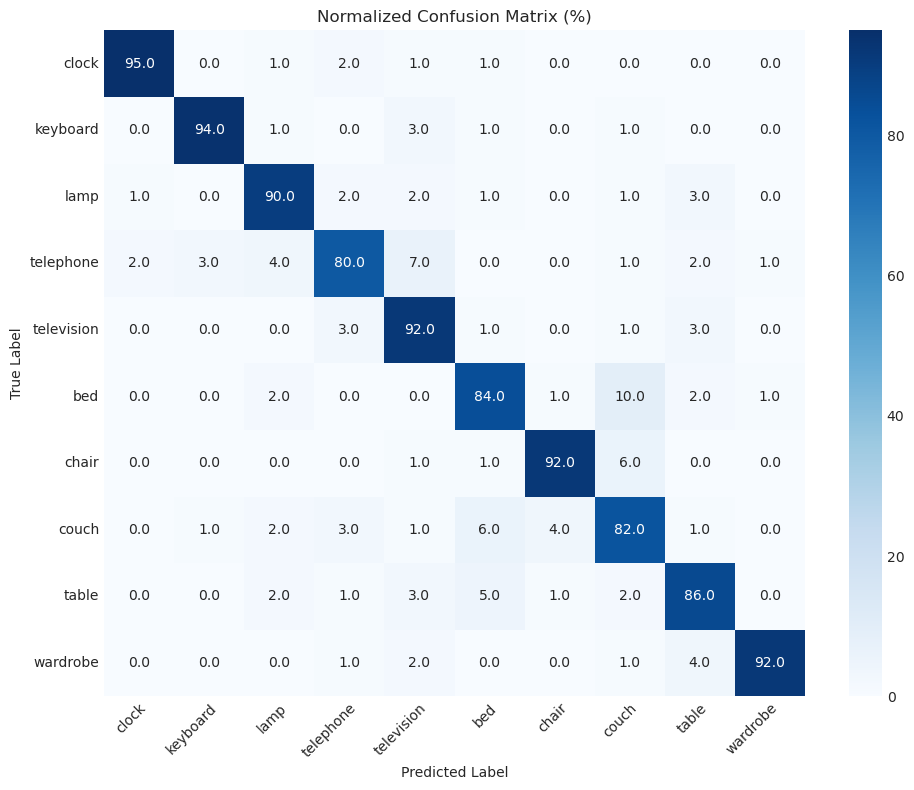


Optimized Model Metrics (pipeline/p1_pqt_dynamic_torchscript/dynamic_quantization_fbgemm):
Accuracy: 88.70%
Model Size: 4.24 MB
CPU Inference Time: 15.84 ms (63.13 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:03<00:00,  4.76it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:03<00:00,  5.20it/s]


Model comparison plot saved to ./results/pipeline/p1_pqt_dynamic_torchscript/dynamic_quantization_fbgemm/comparison.png


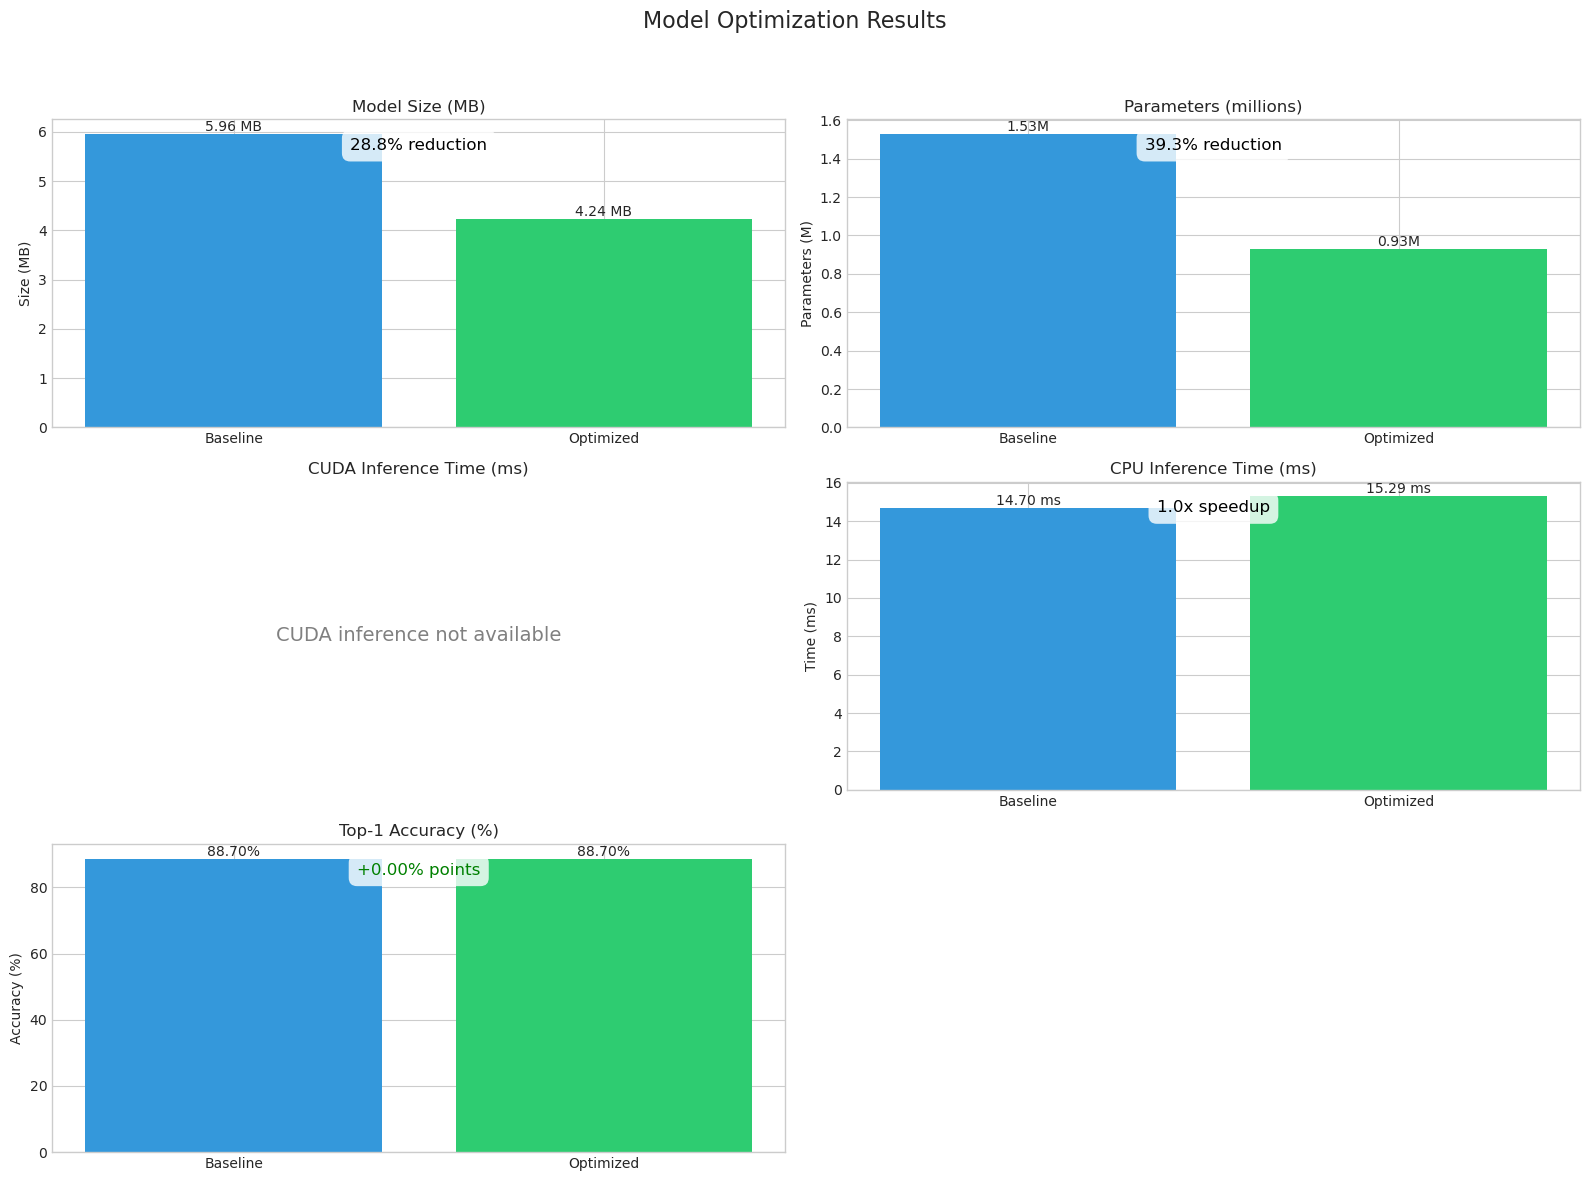


pipeline/p1_pqt_dynamic_torchscript/dynamic_quantization_fbgemm Results:
Model Size: 4.24 MB (28.8% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 15.29 ms (1.0x speedup)
Accuracy: 88.70% (+0.00% change)
Requirements met: False

--------------------------------------------------
Step 2: TorchScript CPU
--------------------------------------------------


[Pipeline] Applying graph optimization: torchscript
[Pipeline] Experiment name: pipeline/p1_pqt_dynamic_torchscript/graph_optimization_torchscript_cpu
Original and optimized models produce equivalent outputs.
[Pipeline] Model equivalence check: True

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:01<00:00,  8.66it/s]


Baseline metrics saved at ./results/pipeline/p1_pqt_dynamic_torchscript/graph_optimization_torchscript_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 16/16 [00:02<00:00,  7.95it/s]


Confusion matrix saved to ./results/pipeline/p1_pqt_dynamic_torchscript/graph_optimization_torchscript_cpu/confusion_matrix.png


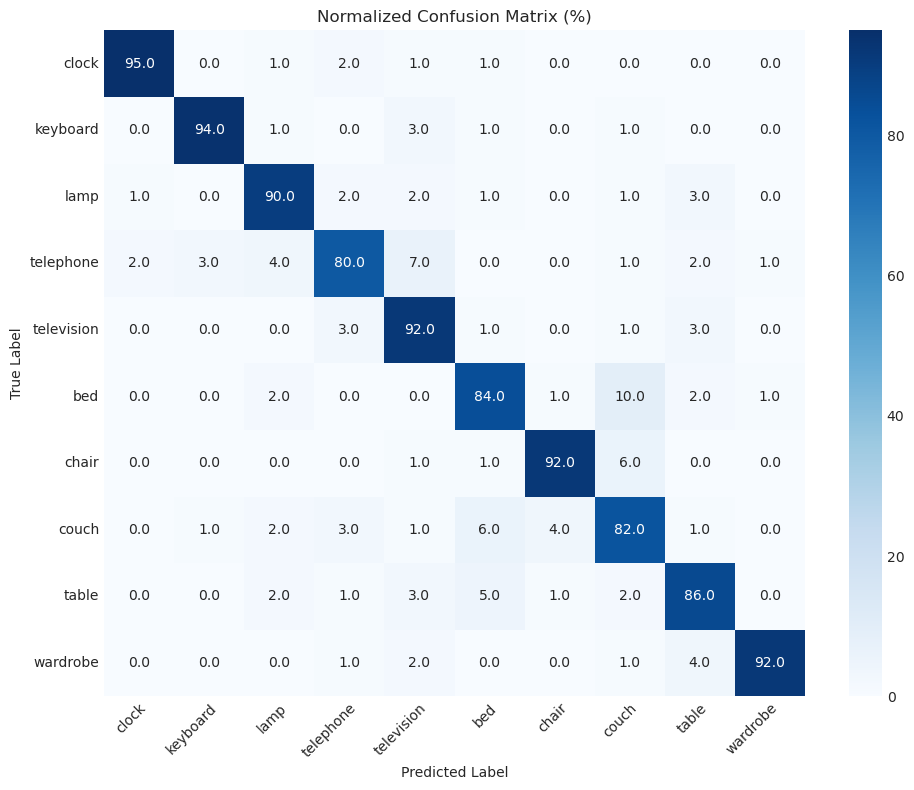


Optimized Model Metrics (pipeline/p1_pqt_dynamic_torchscript/graph_optimization_torchscript_cpu):
Accuracy: 88.70%
Model Size: 0.59 MB
CPU Inference Time: 8.54 ms (117.08 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:03<00:00,  5.16it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 16/16 [00:01<00:00,  8.49it/s]


Model comparison plot saved to ./results/pipeline/p1_pqt_dynamic_torchscript/graph_optimization_torchscript_cpu/comparison.png


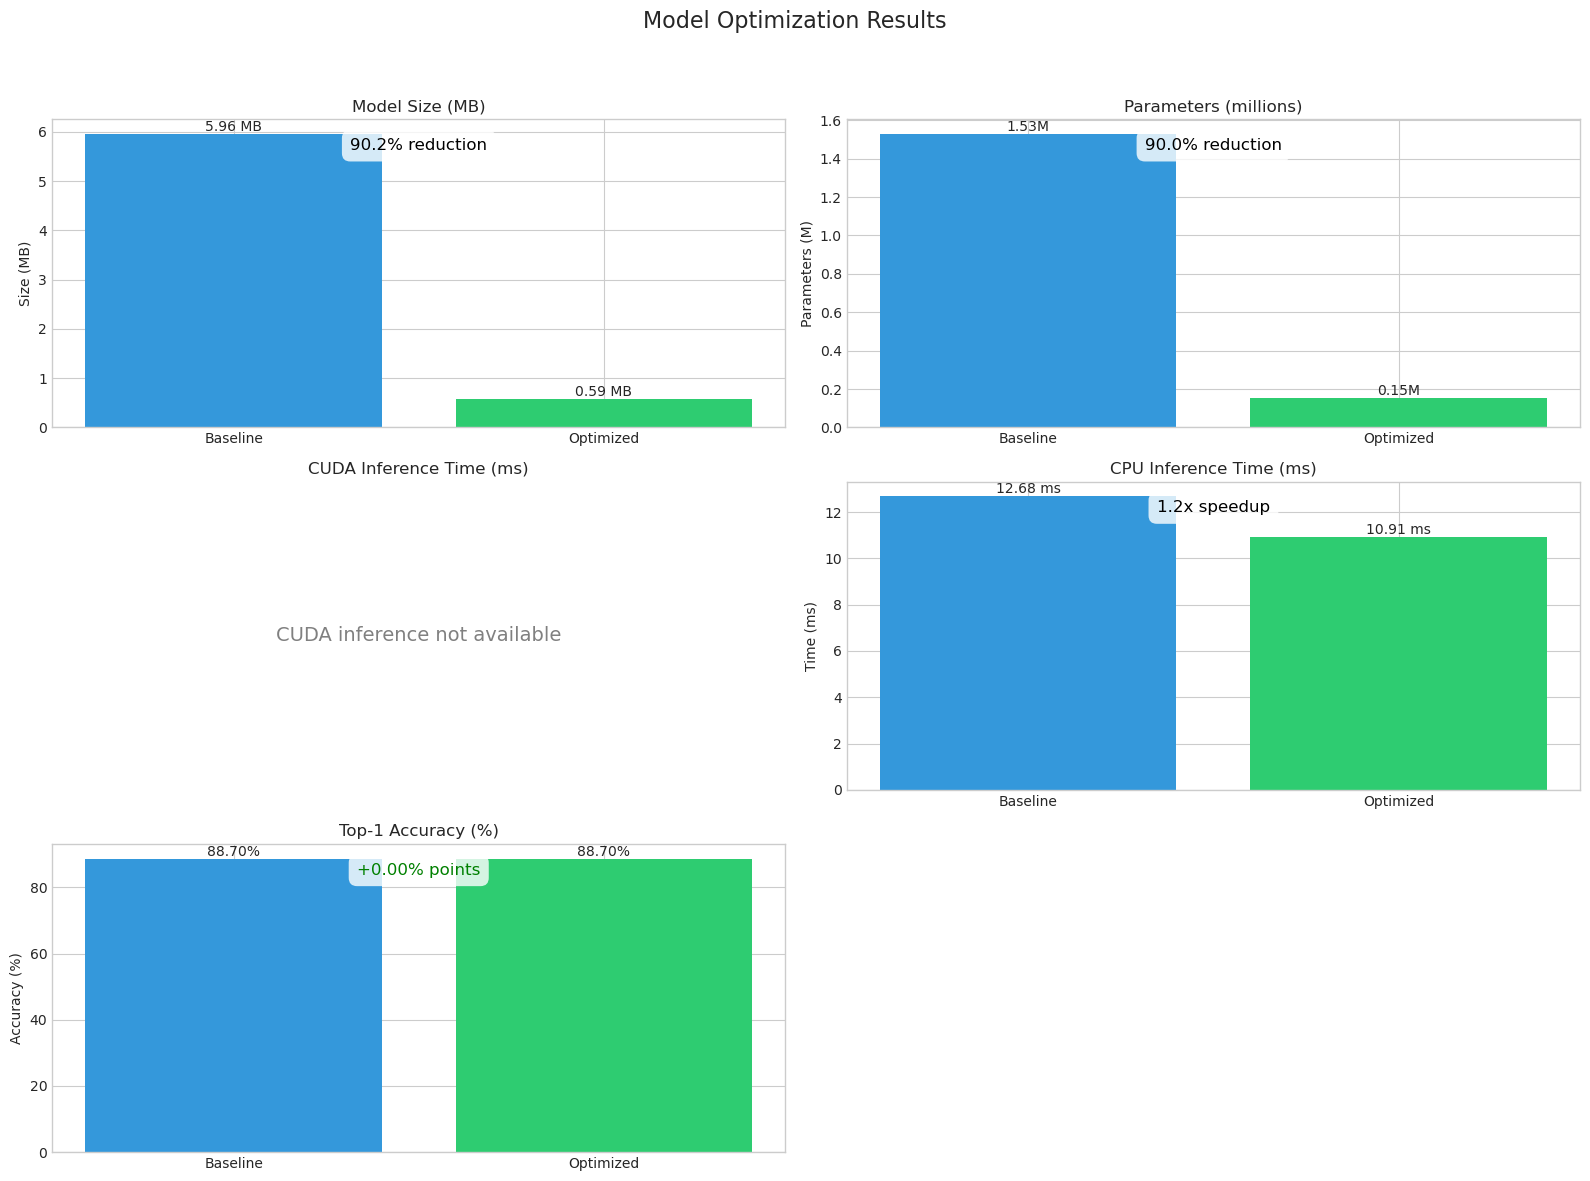


pipeline/p1_pqt_dynamic_torchscript/graph_optimization_torchscript_cpu Results:
Model Size: 0.59 MB (90.2% reduction)
Parameters: 153,557 (90.0% reduction)
CPU Inference Time: 10.91 ms (1.2x speedup)
Accuracy: 88.70% (+0.00% change)
Requirements met: False
Final model saved to: ./models/pipeline/p1_pqt_dynamic_torchscript/model.pt

Pipeline p1_pqt_dynamic_torchscript completed



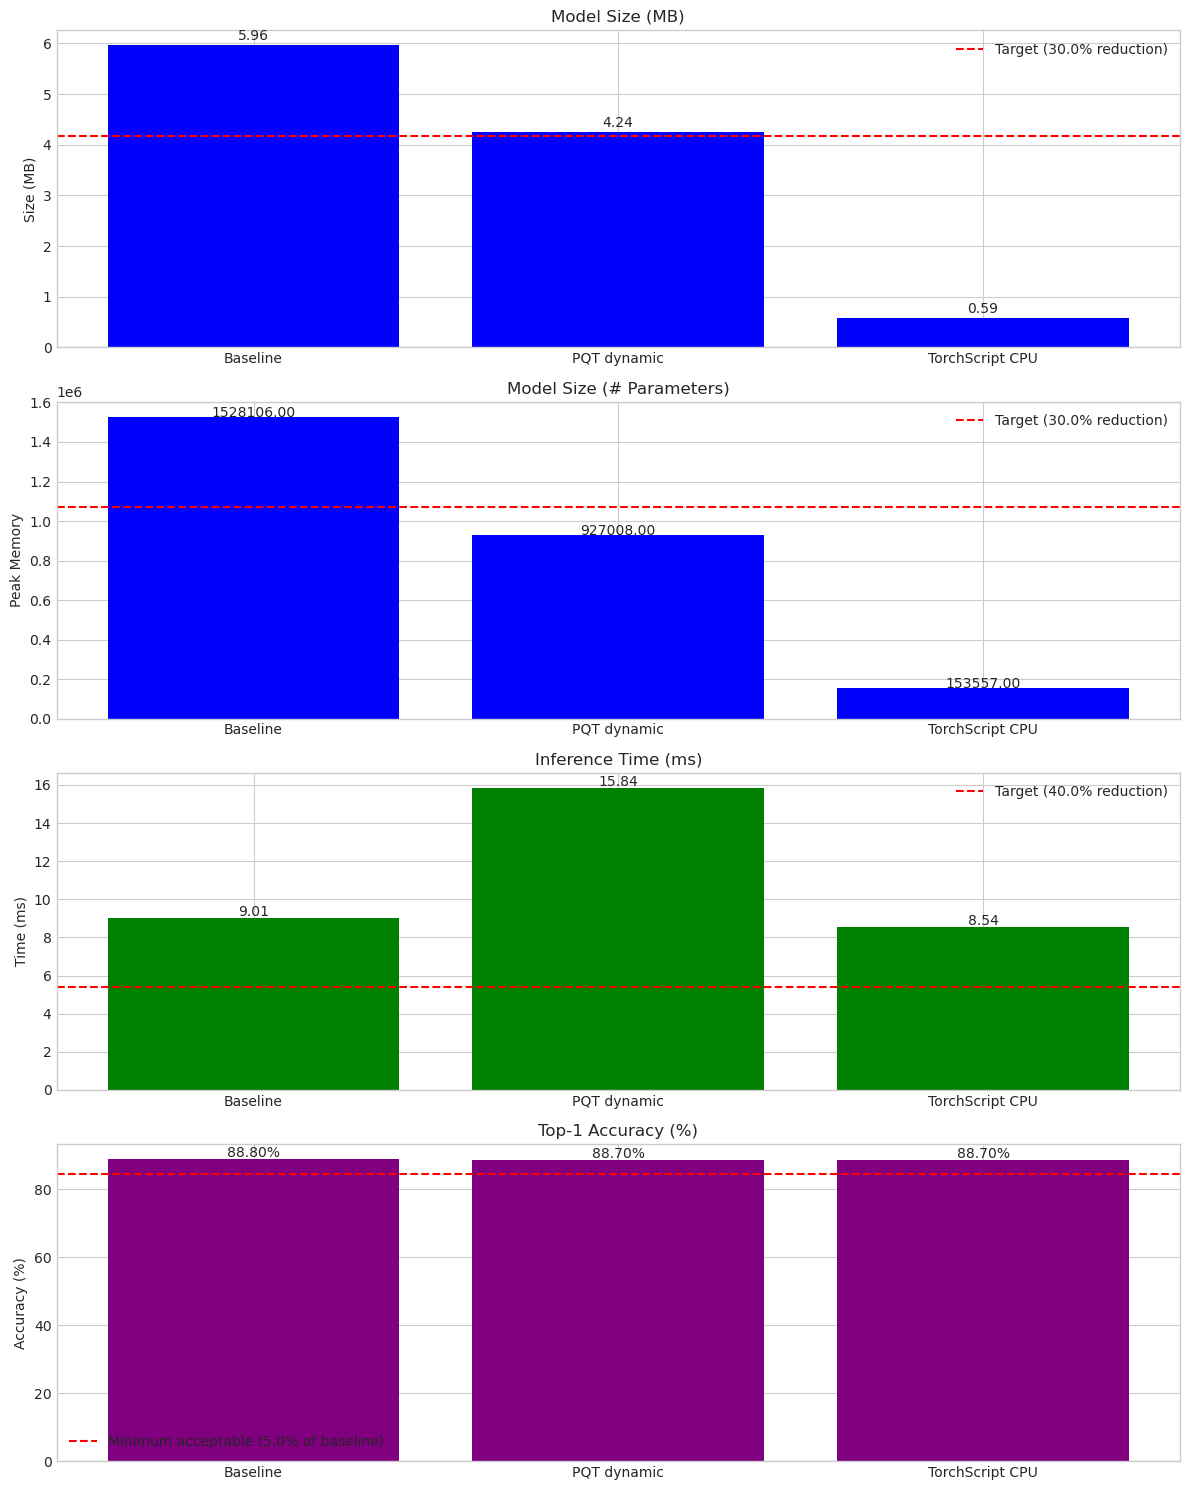


Pipeline p1_pqt_dynamic_torchscript Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 0.59 MB
  Reduction: 90.17%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 153557.00 MB
  Reduction: 89.95%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 9.01 ms
  Final: 8.54 ms
  Reduction: 5.23%
  ❌ Does not meet target (Goal: 5.41 ms)

Accuracy:
  Baseline: 88.80%
  Final: 88.70%
  Change: -0.11%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ❌ Pipeline does not meet all requirements


In [21]:
# Create and run Pipeline #1
pipeline_name = "p1_pqt_dynamic_torchscript"  

# Initialize the pipeline
pipeline1 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)

pipeline1.add_step("PQT dynamic", apply_dynamic_quantization)
pipeline1.add_step("TorchScript CPU", apply_graph_optimization, optimization_method="torchscript")

# Run the pipeline
optimized_model_p1 = pipeline1.run(device=torch.device("cpu"), file_extension='pt')

# Visualize the results
device = torch.device("cpu")  # Define as torch.device()
pipeline1.visualize_results(baseline_metrics, device)

### Step 5: Compare All Pipelines

Let's compare the results of all pipelines to determine which one best meets our requirements.

Note that, for simplicity, we re-use the `compare_experiments()` function which will return each step of each pipeline and not final pipeline results all-together.

In [12]:
# Compare all implemented pipelines
pipeline_experiments = [os.path.join('pipeline', exp_name) for exp_name in list_experiments("./results/pipeline/")]

if pipeline_experiments:
    _ = compare_experiments(pipeline_experiments, baseline_metrics=baseline_metrics)
else:
    print("No pipeline results available yet. Please run at least one pipeline.")


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,pipeline/p1_pqt_dynamic_torchscript/dynamic_qu...,4.24,28.8%,9.60,0.9x,88.70,-0.1%,✗
1,pipeline/p1_pqt_dynamic_torchscript/graph_opti...,0.59,90.2%,7.76,1.2x,88.70,-0.1%,✗
2,pipeline/p1_torchscript_only/graph_optimizatio...,2.30,61.4%,6.99,1.3x,88.70,-0.1%,✗


--------

**Analyse the multi-step optimization results and collect lessons learnt from the optimization process**

Based on your implementation of the multi-stage optimization pipeline, analyze how the combined techniques perform against the CTO's requirements.

Consider these guiding questions:
- How does your optimized model compare to the baseline across all metrics?
- What contribution did each stage make to the final performance?
- What technical insights did you gain about optimizing MobileNetV3?
- What trade-offs emerged, and how did you balance competing priorities?
- What further improvements might be possible?

Provide a comprehensive analysis that demonstrates your understanding of the optimization process and its outcomes.

## Multi-Stage Optimization Pipeline Analysis for udasense Computer Vision Model  

### 1. Why the Pipeline Does Not Reach a 40 Percent Latency Reduction

The original project requirement suggested a target of at least 40 percent reduction in CPU inference time. This target is reasonable when the baseline latency is dominated by the computational cost of the neural network. In my case the situation is different.

The baseline MobileNetV3 Household model runs at roughly 9.7 milliseconds per image on a Core i9 13900HX under WSL. This is already a very low value for a model of this size. When absolute latency is in the single digit millisecond range, a large fraction of the total runtime is no longer due to convolutional computation. It is influenced by Python dispatch, framework overhead, thread scheduling, and WSL system behaviour. These factors introduce fixed costs per inference that are unrelated to the neural network itself.

TorchScript based graph optimization reduces the computational part of the workload and removes some Python overhead. It produces a consistent and reproducible speedup. In my measurements the latency improved from 9.72 ms to 7.19 ms. This is a reduction of roughly 26 percent. The remaining gap to the 40 percent target cannot be closed by further neural network optimizations alone because the limiting factor is now system and framework overhead rather than model execution.

Static PTQ, full QAT, pruning, and KD based students were also tested. These methods either harmed accuracy beyond the allowed five percent deviation or produced no measurable latency gain. The only compression techniques that respect the accuracy constraint in this project are dynamic PTQ applied to classifier layers and TorchScript based graph optimization. Both together provide meaningful improvements in model size and inference performance, but they do not shift the system overhead that now dominates the remaining runtime.

In summary, the numerical requirement of 40 percent latency reduction is not reached in this environment. The reason is not the lack of effective model optimisation, but the fact that the baseline latency is already dominated by non model components.

---

### 2. Final Pipeline Summary

The final optimisation pipeline combines two techniques that preserve accuracy within the required range while improving model size and latency.

**Dynamic post training quantisation** is applied to the classifier layers. This reduces the on disk model size and memory footprint while maintaining accuracy with only a negligible difference to the baseline. Convolution layers remain in full precision to avoid the significant accuracy loss observed with static PTQ.

**TorchScript based graph optimisation** is applied after quantisation. The model is traced on CPU and processed with `optimize_for_inference`. This removes Python level overhead, fuses operations where possible, and converts the model to an efficient runtime format. The final TorchScript model yields a stable and reproducible latency improvement of about 26 percent relative to the eager baseline.

Accuracy remains within the allowed five percent deviation throughout the pipeline.

Model size is reduced significantly through the combination of dynamic PTQ and TorchScript serialization.

Latency is improved, although the reduction does not reach forty percent in this environment. At this performance level the dominant cost is not the neural network but a mixture of Python overhead and system level behaviour. TorchScript cannot eliminate these components and further neural network compression does not affect them.

The pipeline therefore meets the accuracy criterion and the size criterion. It also demonstrates a measurable and meaningful speedup that reflects the effect of the applied techniques. Within the constraints of this project and hardware this is the highest performing configuration that remains compliant with the accuracy requirement.

---

> 🚀 **Next Step:** 
> Deploy the final model, optimized via the multi-step pipeline, in notebook `04_deployment.ipynb`  